pytorchで強化学習のActor-Criticモデルをスクラッチで組む。題材は価格最適化として環境も自作する。<br>⇒正しい理解かは分からないけれど、Actor-Criticの方策勾配式も元を辿れば最適ベルマン方程式になる。<br>⇒つまり、報酬を踏まえた収益を最大にする行動を選択する方策を導き出す。<br>⇒今回は、報酬(1ステップ毎の売上)を踏まえた収益(1エピソードの合計売上)を最大にする行動を選択する方策を導き出す。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
print("numpy: ", np.__version__)
print("torch: ", torch.__version__)

numpy:  2.0.2
torch:  2.8.0+cu126


環境を自作する

In [3]:
MAX_INVENTORY = 100
MAX_STEP_COUNT = 31
STATE = np.array(object=[1.0, 1.0],  # 状態(観察)は[残り在庫の割合, 残りステップの割合]で表現する
                 dtype=np.float32)
PRICE_FOR_ACTION = np.array(object=[100, 120, 140, 160, 180])  # 行動は取り得る価格を選択する事として、取り得る価格は5次元ベクトルで表現する

In [4]:
class PriceEnvironment():
    def __init__(self, max_inventory, max_step_count):
        self.max_inventory = max_inventory
        self.inventory = self.max_inventory
        self.max_step_count = max_step_count
        self.step_count = 0
        self.price_array = PRICE_FOR_ACTION

    def step(self, action_number):
        price = self.price_array[action_number]
        demand_expectation = int((PRICE_FOR_ACTION[-1] / price) * (self.inventory * 0.05))  # 「在庫の5%」×「重み」を「需要の期待値」とする # 「重み」は、最高価格に対する価格の割合の逆数(価格が高いと重みは小さい)とする
        demand = np.random.poisson(lam=demand_expectation,  # 「需要の期待値」を「ポアソン分布の期待値」として、ポアソン分布から「需要」を確率的に得る
                                   size=None)  # 引数sizeをNoneにする事でポアソン分布から1個だけの値を確率的に得る # sizeを100にすると100個の値を確率的に得る形になる
        saled_inventory = min(self.inventory, max(demand, 0))  # 「売れた在庫」は、「需要」と「在庫数」の小さい方の値とする # 「在庫数」以上の「需要」は売れないため
        reward = price * saled_inventory
        self.inventory = self.inventory - saled_inventory
        inventory_ratio = self.inventory / self.max_inventory
        self.step_count = self.step_count + 1
        step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        if self.inventory <= 0 or self.step_count >= self.max_step_count:
            done = 1
        else:
            done = 0
        next_state = np.array(object=[inventory_ratio, step_ratio],
                              dtype=np.float32)
        return reward, next_state, done

    def reset(self):
        self.inventory = self.max_inventory
        self.step_count = 0
        state = STATE
        done = 0
        return state, done

Actor-Criticモデル

In [5]:
class MyActor(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=action_dim)

    def forward(self, in_data):
        out_layer_1 = torch.nn.functional.relu(input=self.layer_1(input=in_data))
        out_layer_2 = torch.nn.functional.softmax(input=self.layer_2(input=out_layer_1),
                                                  dim=1)  # softmax計算をどの軸で行うか
        return out_layer_2


class MyCritic(torch.nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=1)

    def forward(self, in_data):
        out_layer_1 = torch.nn.functional.relu(input=self.layer_1(input=in_data))
        out_layer_2 = self.layer_2(input=out_layer_1)
        return out_layer_2

学習

In [6]:
nn_actor_model = MyActor(state_dim=len(STATE),
                         action_dim=len(PRICE_FOR_ACTION))
nn_critic_model = MyCritic(state_dim=len(STATE))
actor_optimizer = torch.optim.Adam(params=nn_actor_model.parameters(),
                                   lr=0.001)
critic_optimizer = torch.optim.Adam(params=nn_critic_model.parameters(),
                                    lr=0.001)
critic_loss = torch.nn.MSELoss()

In [7]:
nn_actor_model.train()
nn_critic_model.train()
env = PriceEnvironment(max_inventory=MAX_INVENTORY,
                       max_step_count=MAX_STEP_COUNT)
gamma = 0.98
total_reward_list = []
for episode in range(2500):
    state, done = env.reset()
    state = torch.unsqueeze(input=torch.tensor(state),  # ニューラルネットワークモデルに入力できるようにミニバッチ軸を追加
                            dim=0)
    total_reward = 0
    while done == 0:
        action_probabilities = nn_actor_model(in_data=state)  # Actorの推論データ # 今時点の方策πθ
        action_probabilities = torch.squeeze(input=action_probabilities,
                                             dim=0)
        probs = action_probabilities.detach().numpy()
        action = np.random.choice(a=len(PRICE_FOR_ACTION),  # 取り得る値の候補 # arrayでなくスカラーの場合はrange(a)を候補とする
                                  p=probs/probs.sum())  # 合計値を確実に1にする
        action_probability = action_probabilities[action]  # Actorの損失値を計算する時に使う # πθ(At│St)
        reward, next_state, done = env.step(action_number=action)
        next_state = torch.unsqueeze(input=torch.tensor(next_state),  # ニューラルネットワークモデルに入力できるようにミニバッチ軸を追加
                                     dim=0)
        next_state_value = nn_critic_model(in_data=next_state)  # Criticの正解データ(target)を算出するため
        next_state_value = torch.squeeze(input=next_state_value,
                                         dim=0)
        target_value = reward + (gamma * next_state_value)  # Criticの正解データ(target)
        target_value = target_value.detach()
        state_value = nn_critic_model(in_data=state)  # Criticの推論データ
        state_value = torch.squeeze(input=state_value,
                                    dim=0)
        loss_for_critic_model = critic_loss(input=state_value,  # Criticの損失値
                                            target=target_value)
        delta = target_value - state_value  # Actorの損失値を計算する時に使う # R + γV(St+1) - V(St)
        delta = delta.detach()
        loss_for_actor_model = - (torch.log(input=action_probability)) * delta  # Actorの損失値
        critic_optimizer.zero_grad()
        actor_optimizer.zero_grad()
        loss_for_critic_model.backward()
        loss_for_actor_model.backward()
        critic_optimizer.step()
        actor_optimizer.step()
        state = next_state
        total_reward = total_reward + reward
    total_reward_list.append(total_reward)

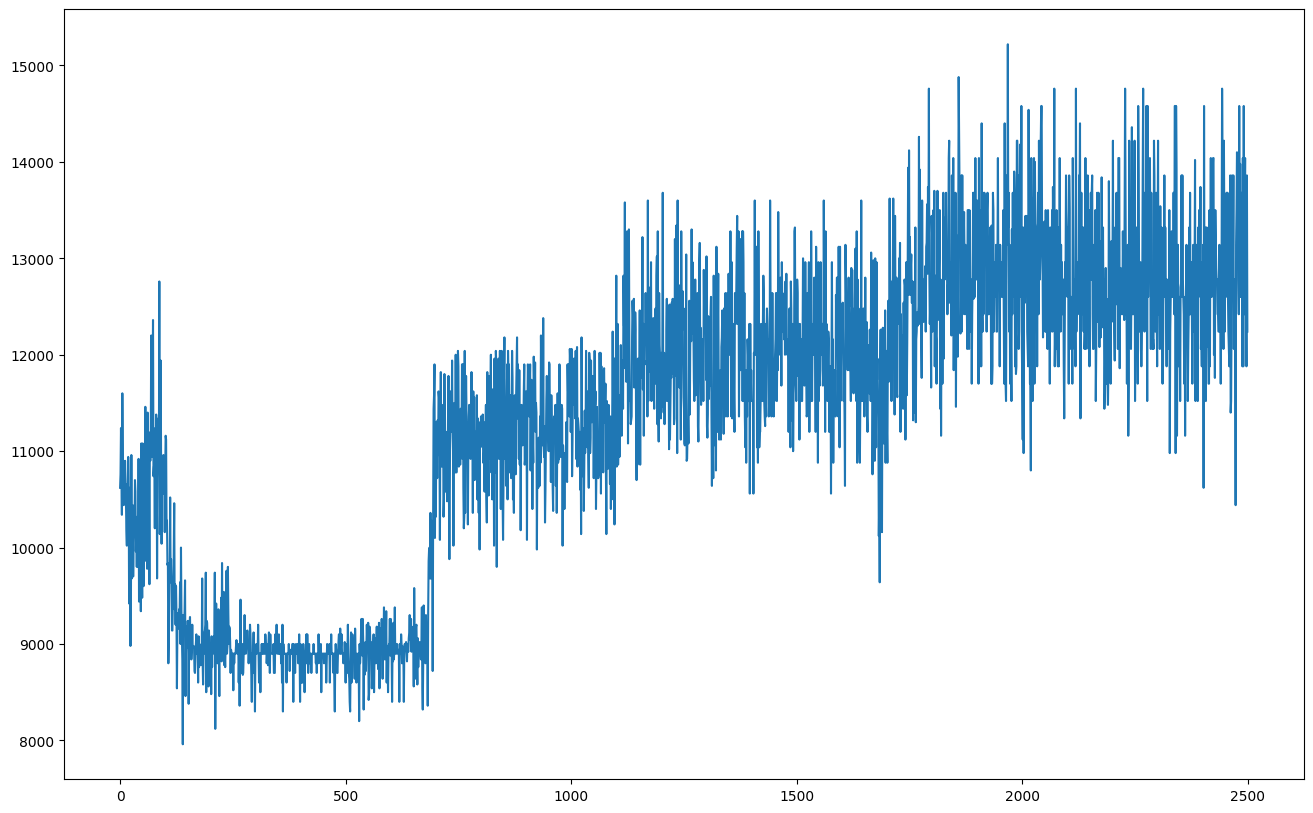

In [8]:
plt.figure(figsize=(16, 10))
plt.plot(range(len(total_reward_list)),
         total_reward_list)
plt.show()